In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
import pandas as pd
import numpy as np

# Definindo as opções para cada variável
opcoes_sim_nao = ['Sim', 'Nao']
opcoes_urgencia = ['Alta', 'Media', 'Baixa']
opcoes_clientes = [f'Cliente_{i}' for i in range(1, 6)] # 5 clientes de exemplo
opcoes_etiquetas = ['Etiqueta_105mm', 'Etiqueta_64mm'] # Apenas dois tipos de etiqueta para simplificar

# Número de exemplos (linhas) que queremos simular
num_amostras = 200 # Reduzindo o número de amostras para facilitar a visualização

# Gerando dados simulados para as variáveis simplificadas
data_simulada_simplificada = {
    'Estoque_OK': np.random.choice(opcoes_sim_nao, num_amostras, p=[0.7, 0.3]), # 70% chance de ter estoque OK
    'Dias_Desde_Pedido': np.random.randint(1, 30, num_amostras), # Dias desde que o pedido foi feito (1 a 29 dias)
    'Urgencia_Pedido': np.random.choice(opcoes_urgencia, num_amostras, p=[0.4, 0.3, 0.3]), # 40% Alta, 30% Media, 30% Baixa
    'Nome_Cliente': np.random.choice(opcoes_clientes, num_amostras),
    'Tempo_Medio_Producao_Min': np.random.randint(20, 180, num_amostras), # Tempo de produção em minutos (20 a 179)
}

# Criando o DataFrame Pandas
df_simples = pd.DataFrame(data_simulada_simplificada)

# --- Criando a variável alvo combinada (Cliente + Etiqueta) ---
df_simples['Produto_A_Ser_Produzido_Cliente'] = '' # Inicializa a coluna

for i in range(len(df_simples)):
    cliente_atual = df_simples.loc[i, 'Nome_Cliente']
    
    # Lógica simplificada para a decisão:
    # Se o estoque estiver OK E a urgência for Alta, há mais chance de ser Etiqueta_105mm.
    # Caso contrário, pode ser Etiqueta_64mm ou a outra.
    if df_simples.loc[i, 'Estoque_OK'] == 'Sim' and df_simples.loc[i, 'Urgencia_Pedido'] == 'Alta':
        produto_escolhido = np.random.choice(['Etiqueta_105mm', 'Etiqueta_64mm'], p=[0.7, 0.3]) # 70% chance de 105mm
    else:
        produto_escolhido = np.random.choice(opcoes_etiquetas) # Escolha aleatória entre as duas

    df_simples.loc[i, 'Produto_A_Ser_Produzido_Cliente'] = f"{cliente_atual}_{produto_escolhido}"

print("Cabeçalho dos nossos dados simulados simplificados:")
print(df_simples.head())

print("\nInformações sobre os tipos de dados (Dtype):")
print(df_simples.info())

print("\nContagem das decisões combinadas (variável alvo):")
print(df_simples['Produto_A_Ser_Produzido_Cliente'].value_counts())

Cabeçalho dos nossos dados simulados simplificados:
  Estoque_OK  Dias_Desde_Pedido Urgencia_Pedido Nome_Cliente  \
0        Sim                 25            Alta    Cliente_1   
1        Sim                 25           Media    Cliente_1   
2        Sim                  2           Media    Cliente_3   
3        Sim                  4           Baixa    Cliente_1   
4        Sim                  4           Media    Cliente_4   

   Tempo_Medio_Producao_Min Produto_A_Ser_Produzido_Cliente  
0                       176         Cliente_1_Etiqueta_64mm  
1                       123        Cliente_1_Etiqueta_105mm  
2                       177         Cliente_3_Etiqueta_64mm  
3                        34         Cliente_1_Etiqueta_64mm  
4                        84         Cliente_4_Etiqueta_64mm  

Informações sobre os tipos de dados (Dtype):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                           Non

In [3]:
# Separando as variáveis (features) da variável alvo (target)
# X serão as variáveis de entrada (o que a IA vai "observar")
# y será a variável que a IA vai "prever" (a decisão combinada)
X_simples = df_simples.drop('Produto_A_Ser_Produzido_Cliente', axis=1) # Remove a coluna alvo de X
y_simples = df_simples['Produto_A_Ser_Produzido_Cliente'] # Seleciona apenas a coluna alvo

# Convertendo variáveis categóricas em numéricas usando One-Hot Encoding
X_simples = pd.get_dummies(X_simples, columns=[
    'Estoque_OK',
    'Urgencia_Pedido',
    'Nome_Cliente'
])

print("Cabeçalho dos dados preparados (X_simples) - agora com colunas numéricas:")
print(X_simples.head())

print("\nInformações sobre os tipos de dados de X_simples (Dtype):")
print(X_simples.info())

Cabeçalho dos dados preparados (X_simples) - agora com colunas numéricas:
   Dias_Desde_Pedido  Tempo_Medio_Producao_Min  Estoque_OK_Nao  \
0                 25                       176           False   
1                 25                       123           False   
2                  2                       177           False   
3                  4                        34           False   
4                  4                        84           False   

   Estoque_OK_Sim  Urgencia_Pedido_Alta  Urgencia_Pedido_Baixa  \
0            True                  True                  False   
1            True                 False                  False   
2            True                 False                  False   
3            True                 False                   True   
4            True                 False                  False   

   Urgencia_Pedido_Media  Nome_Cliente_Cliente_1  Nome_Cliente_Cliente_2  \
0                  False                    True        

In [4]:
from sklearn.model_selection import train_test_split

# Dividindo os dados em conjuntos de treinamento e teste
# test_size=0.20 significa que 20% dos dados serão para teste e 80% para treinamento
# random_state=42 garante que a divisão seja a mesma toda vez que você rodar o código (para reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X_simples, y_simples, test_size=0.20, random_state=42)

print(f"Tamanho total dos dados de entrada (X): {X_simples.shape}")
print(f"Tamanho dos dados de treinamento (X_train): {X_train.shape}")
print(f"Tamanho dos dados de teste (X_test): {X_test.shape}")
print(f"Tamanho dos dados alvo de treinamento (y_train): {y_train.shape}")
print(f"Tamanho dos dados alvo de teste (y_test): {y_test.shape}")

Tamanho total dos dados de entrada (X): (200, 12)
Tamanho dos dados de treinamento (X_train): (160, 12)
Tamanho dos dados de teste (X_test): (40, 12)
Tamanho dos dados alvo de treinamento (y_train): (160,)
Tamanho dos dados alvo de teste (y_test): (40,)


In [5]:
from sklearn.tree import DecisionTreeClassifier

# 1. Criar o modelo da Árvore de Decisão
# random_state=42 é para garantir que os resultados sejam os mesmos toda vez que você rodar
model = DecisionTreeClassifier(random_state=42)

# 2. Treinar o modelo
# Aqui o modelo aprende a mapear as variáveis de entrada (X_train) para as decisões (y_train)
model.fit(X_train, y_train)

print("Modelo de Árvore de Decisão treinado com sucesso!")

Modelo de Árvore de Decisão treinado com sucesso!


In [6]:
from sklearn.metrics import accuracy_score

# 1. Fazer previsões nos dados de teste
# O modelo agora tenta prever a decisão para os dados que ele nunca viu
y_pred = model.predict(X_test)

# 2. Avaliar a acurácia do modelo
# Comparamos as previsões do modelo (y_pred) com as respostas corretas reais (y_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"A acurácia do modelo nos dados de teste é: {acuracia:.2f}")

A acurácia do modelo nos dados de teste é: 0.55


In [7]:
import pandas as pd # Re-importar para ter certeza que está disponível (boa prática em novas celulas)

# Criando um "novo pedido" de exemplo para o modelo prever
# ESTES SÃO OS DADOS QUE VOCÊ DARIA PARA A IA PARA ELA TE DIZER QUAL PRODUTO PRODUZIR
novo_pedido = pd.DataFrame({
    'Estoque_OK': ['Sim'],
    'Dias_Desde_Pedido': [5],
    'Urgencia_Pedido': ['Alta'],
    'Nome_Cliente': ['Cliente_1'],
    'Tempo_Medio_Producao_Min': [60]
})

print("Novo pedido para previsão:")
print(novo_pedido)

# 1. Transformar o "novo pedido" da mesma forma que os dados de treinamento
# Precisamos aplicar o One-Hot Encoding nas mesmas colunas categóricas
novo_pedido_processado = pd.get_dummies(novo_pedido, columns=[
    'Estoque_OK',
    'Urgencia_Pedido',
    'Nome_Cliente'
])

# 2. Garantir que as colunas do "novo pedido" correspondam às colunas de treinamento (X_train)
# É crucial que as colunas sejam idênticas, mesmo que alguns 0s sejam adicionados
colunas_treinamento = X_train.columns
novo_pedido_final = novo_pedido_processado.reindex(columns=colunas_treinamento, fill_value=0)


# 3. Fazer a previsão
previsao = model.predict(novo_pedido_final)

print("\n--- A IA SUGERE PRODUZIR: ---")
print(previsao[0]) # [0] para pegar o primeiro (e único) resultado da lista


Novo pedido para previsão:
  Estoque_OK  Dias_Desde_Pedido Urgencia_Pedido Nome_Cliente  \
0        Sim                  5            Alta    Cliente_1   

   Tempo_Medio_Producao_Min  
0                        60  

--- A IA SUGERE PRODUZIR: ---
Cliente_1_Etiqueta_105mm


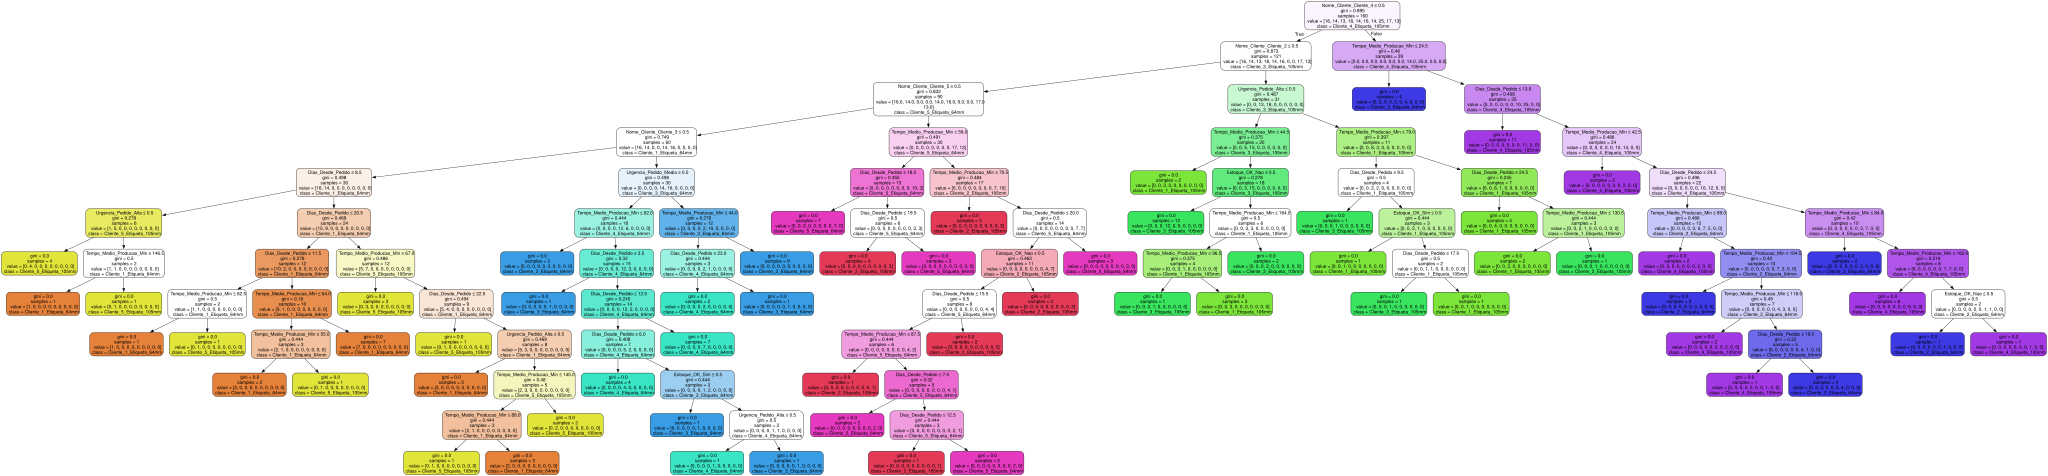

In [8]:
from sklearn.tree import export_graphviz
import graphviz

# Gerar o arquivo DOT da árvore
# feature_names são os nomes das colunas de entrada (X_train.columns)
# class_names são os nomes das decisões que a IA prevê (y_train.unique())
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X_train.columns,
    class_names=y_train.unique(),
    filled=True,
    rounded=True,
    special_characters=True
)

# Renderizar o gráfico da árvore
graph = graphviz.Source(dot_data)
graph